In [1]:
!pip install pandas matplotlib

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
conn = sqlite3.connect("sales_data.db")

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

conn.commit()

print("Database and table created successfully!")

Database and table created successfully!


In [4]:
sales = [
    ("Laptop", 5, 60000),
    ("Mouse", 20, 500),
    ("Keyboard", 15, 1200),
    ("Monitor", 7, 15000),
    ("Headphones", 12, 2500),
    ("Speaker", 10, 3500),
    ("USB Cable", 30, 250)
]

cursor.executemany(
    "INSERT INTO sales(product, quantity, price) VALUES (?, ?, ?)",
    sales
)

conn.commit()

print("Sample data inserted successfully!")

Sample data inserted successfully!


In [5]:
df = pd.read_sql_query("SELECT * FROM sales", conn)
df

,id,product,quantity,price
0,1,Laptop,5,60000.0
1,2,Mouse,20,500.0
2,3,Keyboard,15,1200.0
3,4,Monitor,7,15000.0
4,5,Headphones,12,2500.0
5,6,Speaker,10,3500.0
6,7,USB Cable,30,250.0


In [6]:
query = """
SELECT
    product,
    SUM(quantity) AS total_quantity,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

summary = pd.read_sql_query(query, conn)

summary

,product,total_quantity,revenue
0,Headphones,12,30000.0
1,Keyboard,15,18000.0
2,Laptop,5,300000.0
3,Monitor,7,105000.0
4,Mouse,20,10000.0
5,Speaker,10,35000.0
6,USB Cable,30,7500.0


In [7]:
print("Sales Summary")
print(summary)

Sales Summary
      product  total_quantity   revenue
0  Headphones              12   30000.0
1    Keyboard              15   18000.0
2      Laptop               5  300000.0
3     Monitor               7  105000.0
4       Mouse              20   10000.0
5     Speaker              10   35000.0
6   USB Cable              30    7500.0


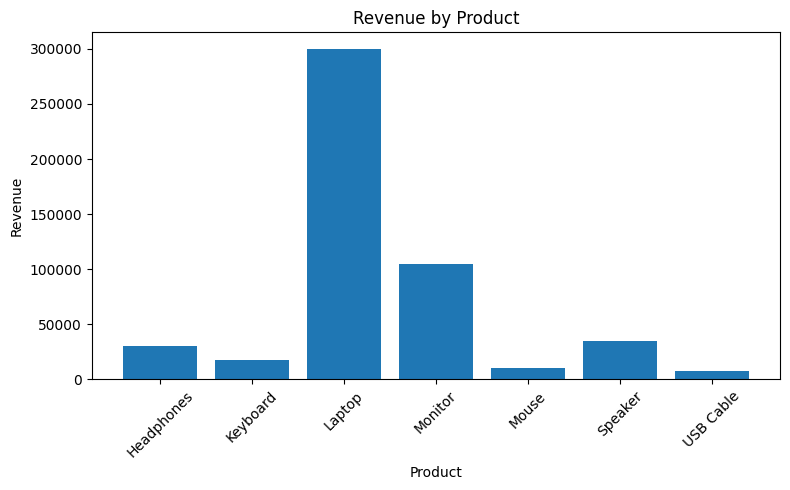

In [8]:
plt.figure(figsize=(8,5))

plt.bar(summary["product"], summary["revenue"])

plt.title("Revenue by Product")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("sales_chart.png")

plt.show()

In [9]:
conn.close()

print("Database connection closed.")

Database connection closed.
